# Exploratory Data Analysis (EDA)

## Objective

The goal of this phase is to explore customer demographics, service usage patterns, billing characteristics, and churn behavior to identify key drivers of customer attrition.

In [1]:
%pip install seaborn

In [2]:
# ============================
# Import Libraries
# ============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# ============================
# Load Clean Dataset
# ============================

df = pd.read_csv(
    "/drive/customer-churn-analytics-project/data/customer_churn_cleaned.csv"
)

df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
# Dataset Shape

df.shape

(7032, 26)

In [4]:
# Churn Distribution

df["Churn Value"].value_counts()

Churn Value
0    5163
1    1869
Name: count, dtype: int64

In [5]:
# Churn Rate

churn_rate = df["Churn Value"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.58%


# Churn Distribution Analysis

Understanding the proportion of customers who left the company provides an initial view of the churn problem and establishes a baseline for further analysis.

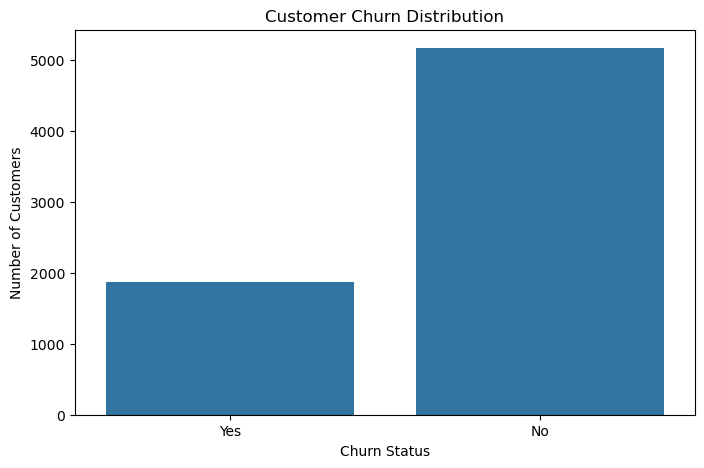

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### Insight

The dataset shows a larger proportion of retained customers compared to churned customers. However, the churned segment still represents a significant business concern and warrants deeper investigation into the factors driving customer attrition.

# Customer Demographics Analysis

This section explores customer demographics and their relationship with churn behavior.

Key demographic variables include:

- Gender
- Senior Citizen Status
- Dependents
- Partner Status

In [7]:
gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn Label"],
    normalize="index"
) * 100

gender_churn.round(2)

Churn Label,No,Yes
Gender,,
Female,73.04,26.96
Male,73.80,26.20


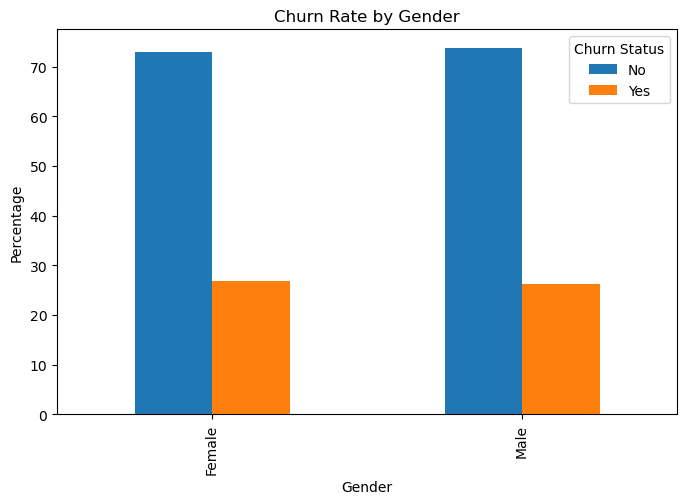

In [8]:
gender_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Gender")
plt.ylabel("Percentage")
plt.xlabel("Gender")

plt.legend(title="Churn Status")

plt.show()

### Insight

The churn rate appears relatively similar across male and female customers, suggesting that gender alone is not a strong predictor of customer attrition.

In [9]:
senior_churn = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100

senior_churn.round(2)

Churn Label,No,Yes
Senior Citizen,,
No,76.35,23.65
Yes,58.32,41.68


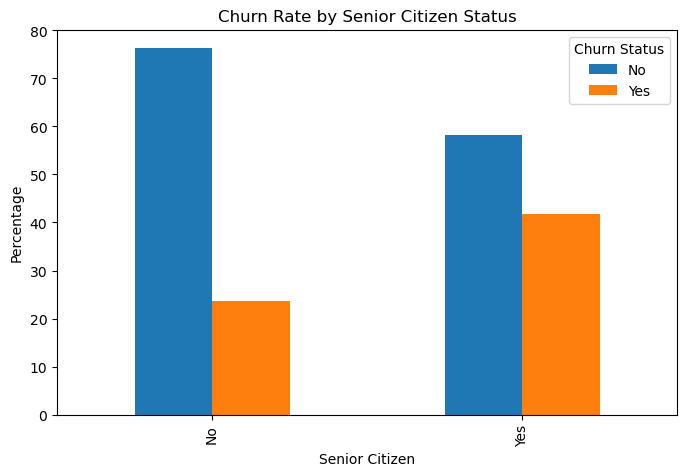

In [10]:
senior_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.ylabel("Percentage")
plt.xlabel("Senior Citizen")

plt.legend(title="Churn Status")

plt.show()

### Insight

Senior citizens generally exhibit higher churn rates than non-senior customers, indicating that age-related customer needs may influence retention.

In [11]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn Label"],
    normalize="index"
) * 100

partner_churn.round(2)

Churn Label,No,Yes
Partner,,
No,67.02,32.98
Yes,80.28,19.72


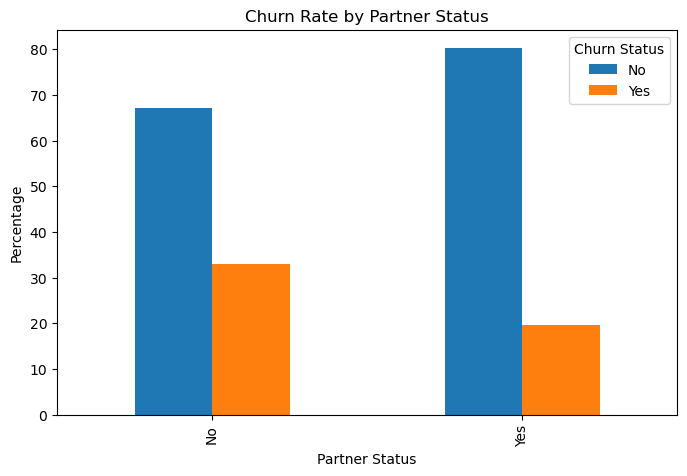

In [12]:
partner_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Partner Status")
plt.ylabel("Percentage")
plt.xlabel("Partner Status")

plt.legend(title="Churn Status")

plt.show()

In [13]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn Label"],
    normalize="index"
) * 100

dependents_churn.round(2)

Churn Label,No,Yes
Dependents,,
No,67.42,32.58
Yes,93.46,6.54


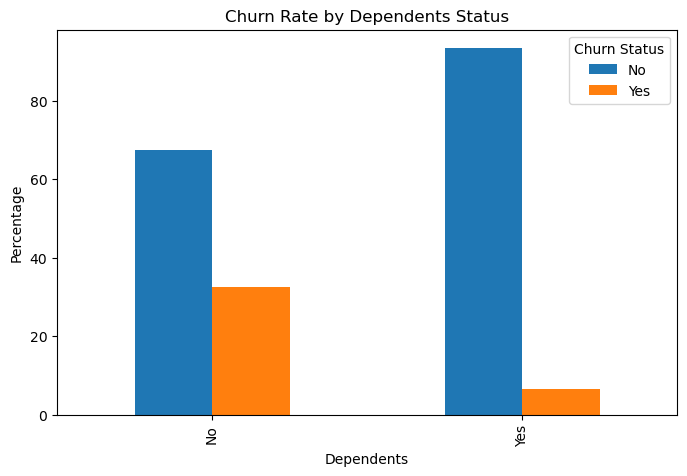

In [14]:
dependents_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Dependents Status")
plt.ylabel("Percentage")
plt.xlabel("Dependents")

plt.legend(title="Churn Status")

plt.show()

### Insight

Customers without dependents exhibit a churn rate of 32.58%, compared to only 6.54% among customers with dependents.

This suggests that customers with stronger household commitments tend to remain with the company for longer periods and are less likely to churn.

# Demographic Findings

The demographic analysis reveals significant differences in churn behavior across customer groups.

Senior citizens exhibit a substantially higher churn rate than younger customers, while customers without partners or dependents are considerably more likely to leave the service.

Notably, customers without dependents show a churn rate of 32.58%, compared to only 6.54% among customers with dependents.

These findings suggest that household stability and life stage are important factors influencing customer retention.